In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import copy

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

sns.set_style("whitegrid")
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

CONFIG = {
    "raw_csv_path": "Data\weatherHistory.csv",
    "ts_features": ["Temperature (C)", "Humidity", "Wind Speed (km/h)", "Pressure (millibars)"],
    "static_features": ["Month", "DayOfYear"],
    "target_col": "Temperature (C)",
    "window_size": 3,
    "forecast_horizon": 7,
    "train_split": 0.8,
    "val_split": 0.1,
    "epochs": 30,
    "batch_size": 32,
    "learning_rate": 0.001,
    "early_stopping_patience": 5,
}

print("Configuration loaded:")
print(json.dumps({k: v for k, v in CONFIG.items() if k != "raw_csv_path"}, indent=2))

Using device: cuda
Configuration loaded:
{
  "ts_features": [
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Pressure (millibars)"
  ],
  "static_features": [
    "Month",
    "DayOfYear"
  ],
  "target_col": "Temperature (C)",
  "window_size": 3,
  "forecast_horizon": 7,
  "train_split": 0.8,
  "val_split": 0.1,
  "epochs": 30,
  "batch_size": 32,
  "learning_rate": 0.001,
  "early_stopping_patience": 5
}


In [16]:
import pandas as pd

# Load data from the path defined in CONFIG
df = pd.read_csv(CONFIG['raw_csv_path'])

# Convert Formatted Date to datetime objects
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

# Sort by date to ensure time series continuity
df = df.sort_values('Formatted Date')

print(f"Data loaded. Shape: {df.shape}")
display(df.head())

Data loaded. Shape: (96453, 12)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
2880,2005-12-31 23:00:00+00:00,Partly Cloudy,rain,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,0.0,1016.66,Mostly cloudy throughout the day.
2881,2006-01-01 00:00:00+00:00,Mostly Cloudy,rain,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,0.0,1016.15,Mostly cloudy throughout the day.
2882,2006-01-01 01:00:00+00:00,Mostly Cloudy,rain,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,0.0,1015.87,Mostly cloudy throughout the day.
2883,2006-01-01 02:00:00+00:00,Overcast,rain,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,0.0,1015.56,Mostly cloudy throughout the day.
2884,2006-01-01 03:00:00+00:00,Mostly Cloudy,rain,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,0.0,1014.98,Mostly cloudy throughout the day.


PHASE 2: EXPLORATORY DATA ANALYSIS


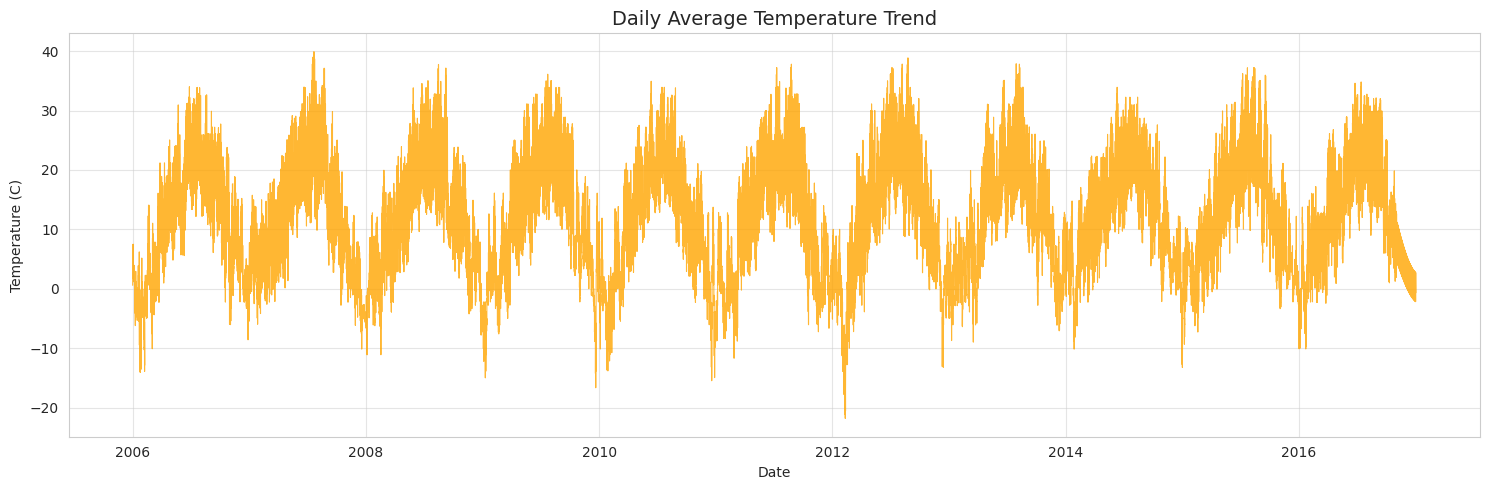

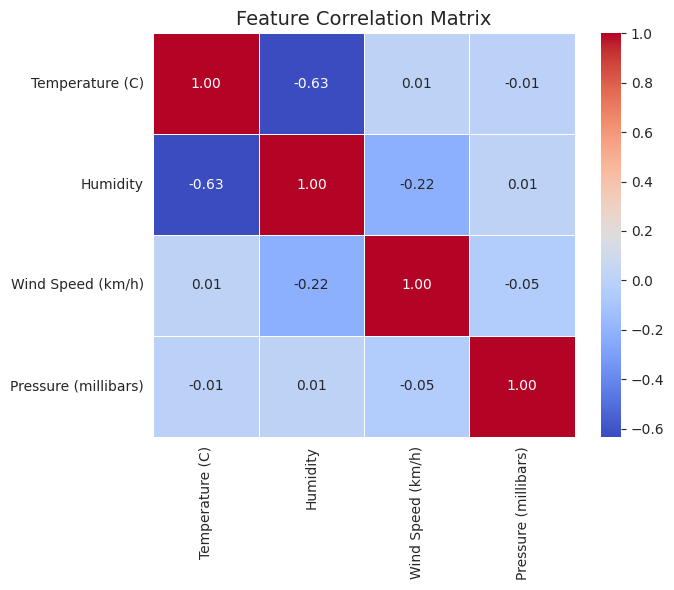

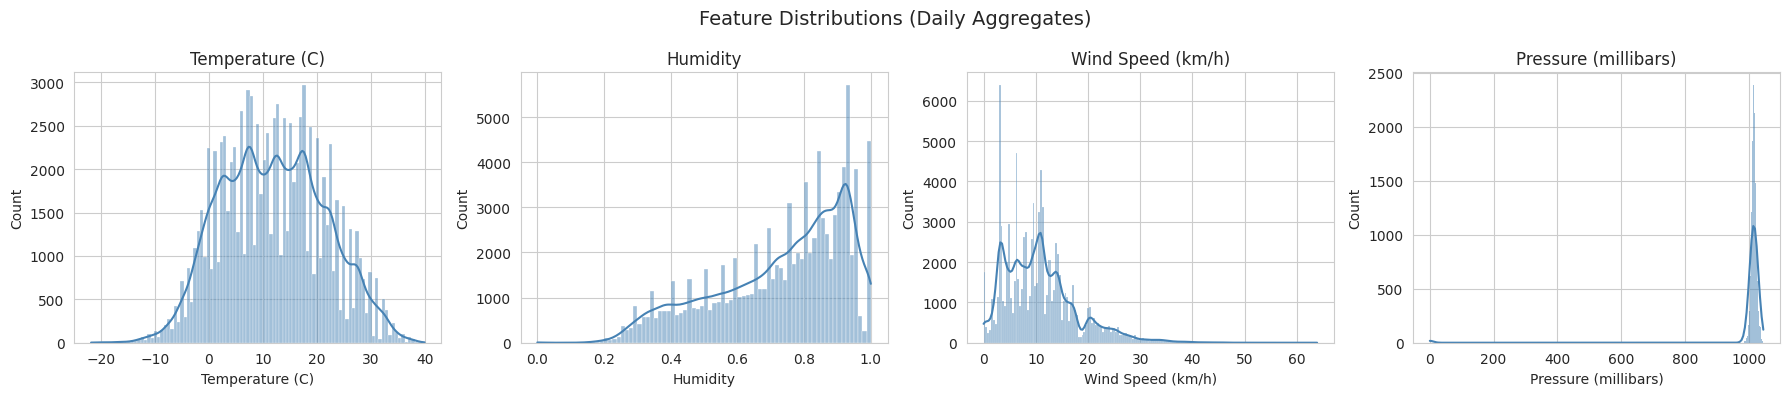

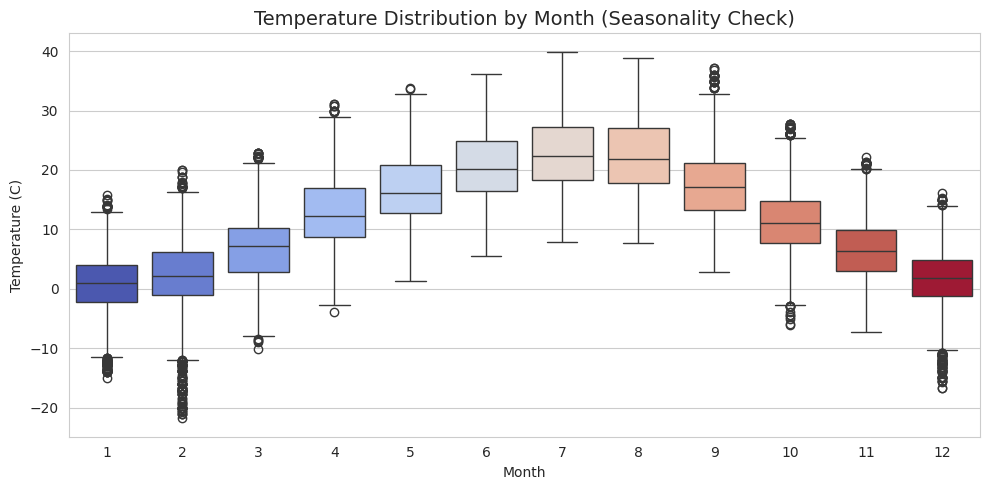

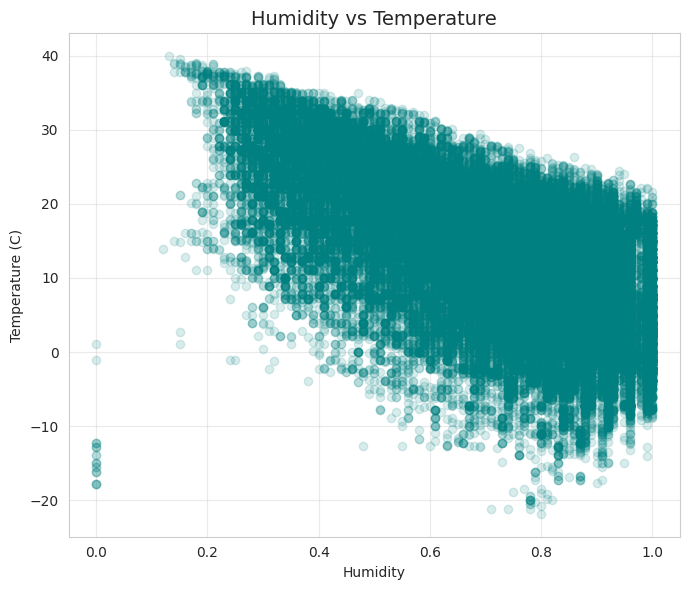

In [17]:
print("=" * 70)
print("PHASE 2: EXPLORATORY DATA ANALYSIS")
print("=" * 70)

plt.figure(figsize=(15, 5))
plt.plot(df["Formatted Date"], df["Temperature (C)"], color="orange", alpha=0.8, linewidth=0.8)
plt.title("Daily Average Temperature Trend", fontsize=14)
plt.xlabel("Date"); plt.ylabel("Temperature (C)")
plt.grid(True, alpha=0.5)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 6))
sns.heatmap(df[CONFIG["ts_features"]].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(CONFIG["ts_features"]), figsize=(18, 4))
for ax, col in zip(axes, CONFIG["ts_features"]):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.suptitle("Feature Distributions (Daily Aggregates)", fontsize=14)
plt.tight_layout(); plt.show()

df["_Month"] = df["Formatted Date"].dt.month
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="_Month", y="Temperature (C)", hue="_Month", palette="coolwarm", legend=False)
plt.title("Temperature Distribution by Month (Seasonality Check)", fontsize=14)
plt.xlabel("Month"); plt.ylabel("Temperature (C)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(df["Humidity"], df["Temperature (C)"], alpha=0.15, color="teal")
plt.title("Humidity vs Temperature", fontsize=14)
plt.xlabel("Humidity"); plt.ylabel("Temperature (C)")
plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

df.drop(columns=["_Month"], inplace=True)

In [18]:
print("=" * 70)
print("PHASE 3: FEATURE ENGINEERING & PREPROCESSING")
print("=" * 70)

df["Month"] = df["Formatted Date"].dt.month
df["DayOfYear"] = df["Formatted Date"].dt.dayofyear

ts_features = CONFIG["ts_features"]
static_features = CONFIG["static_features"]
target_col = CONFIG["target_col"]
window_size = CONFIG["window_size"]
forecast_horizon = CONFIG["forecast_horizon"]

scaler_ts = MinMaxScaler()
scaler_static = MinMaxScaler()
scaler_target = MinMaxScaler()

ts_scaled = scaler_ts.fit_transform(df[ts_features])
static_scaled = scaler_static.fit_transform(df[static_features])
target_scaled = scaler_target.fit_transform(df[[target_col]])

X_ts, X_static, y = [], [], []
for i in range(len(df) - window_size - forecast_horizon + 1):
    X_ts.append(ts_scaled[i: i + window_size])
    future_static = static_scaled[i + window_size: i + window_size + forecast_horizon].flatten()
    X_static.append(future_static)
    y.append(target_scaled[i + window_size: i + window_size + forecast_horizon, 0])

X_ts = np.array(X_ts)
X_static = np.array(X_static)
y = np.array(y)

print(f"\nX_ts shape:     {X_ts.shape}")
print(f"X_static shape: {X_static.shape}")
print(f"y shape:        {y.shape}")

split_idx = int(CONFIG["train_split"] * len(X_ts))
X_ts_train, X_ts_test = X_ts[:split_idx], X_ts[split_idx:]
X_static_train, X_static_test = X_static[:split_idx], X_static[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

test_target_dates = [
    df["Formatted Date"].iloc[i + window_size: i + window_size + forecast_horizon].tolist()
    for i in range(split_idx, len(df) - window_size - forecast_horizon + 1)
]

print(f"\nTrain samples: {len(X_ts_train):,}   Test samples: {len(X_ts_test):,}")

PHASE 3: FEATURE ENGINEERING & PREPROCESSING

X_ts shape:     (96444, 3, 4)
X_static shape: (96444, 14)
y shape:        (96444, 7)

Train samples: 77,155   Test samples: 19,289


In [19]:
print("=" * 70)
print("PHASE 4: MODEL ARCHITECTURES")
print("=" * 70)

n_ts_features = len(ts_features)
static_input_dim = forecast_horizon * len(static_features)


def naive_persistence_predict(X_ts_scaled, target_feature_idx=0, horizon=forecast_horizon):
    last_known_scaled = X_ts_scaled[:, -1, target_feature_idx]
    return np.repeat(last_known_scaled[:, None], horizon, axis=1)


class BaselineLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=64, dense_size=32, horizon=forecast_horizon):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, batch_first=True)
        self.dense = nn.Linear(hidden_size, dense_size)
        self.relu = nn.ReLU()
        self.output = nn.Linear(dense_size, horizon)

    def forward(self, x_ts):
        _, (h_n, _) = self.lstm(x_ts)
        h_last = h_n[-1]
        x = self.relu(self.dense(h_last))
        return self.output(x)


class HybridLSTM_MLP(nn.Module):
    def __init__(self, n_features, static_dim, hidden_size=64, static_dense=32,
                 combined_dense=64, horizon=forecast_horizon):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, batch_first=True)
        self.static_dense = nn.Linear(static_dim, static_dense)
        self.relu = nn.ReLU()
        self.combined_dense = nn.Linear(hidden_size + static_dense, combined_dense)
        self.output = nn.Linear(combined_dense, horizon)

    def forward(self, x_ts, x_static):
        _, (h_n, _) = self.lstm(x_ts)
        h_last = h_n[-1]
        static_out = self.relu(self.static_dense(x_static))
        combined = torch.cat([h_last, static_out], dim=1)
        x = self.relu(self.combined_dense(combined))
        return self.output(x)


baseline_model = BaselineLSTM(n_ts_features).to(DEVICE)
hybrid_model = HybridLSTM_MLP(n_ts_features, static_input_dim).to(DEVICE)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("\n--- Baseline Model (LSTM only) ---")
print(baseline_model)
print(f"Trainable parameters: {count_params(baseline_model):,}")

print("\n--- Hybrid Model (LSTM + MLP) ---")
print(hybrid_model)
print(f"Trainable parameters: {count_params(hybrid_model):,}")

PHASE 4: MODEL ARCHITECTURES

--- Baseline Model (LSTM only) ---
BaselineLSTM(
  (lstm): LSTM(4, 64, batch_first=True)
  (dense): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=32, out_features=7, bias=True)
)
Trainable parameters: 20,231

--- Hybrid Model (LSTM + MLP) ---
HybridLSTM_MLP(
  (lstm): LSTM(4, 64, batch_first=True)
  (static_dense): Linear(in_features=14, out_features=32, bias=True)
  (relu): ReLU()
  (combined_dense): Linear(in_features=96, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=7, bias=True)
)
Trainable parameters: 25,063


In [20]:
print("=" * 70)
print("PHASE 5: MODEL TRAINING")
print("=" * 70)


class EarlyStopper:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.counter += 1
        return self.counter >= self.patience


n_val = int(CONFIG["val_split"] * len(X_ts_train))
n_fit = len(X_ts_train) - n_val

X_ts_fit, X_ts_val = X_ts_train[:n_fit], X_ts_train[n_fit:]
X_static_fit, X_static_val = X_static_train[:n_fit], X_static_train[n_fit:]
y_fit, y_val = y_train[:n_fit], y_train[n_fit:]

t_X_ts_fit = torch.tensor(X_ts_fit, dtype=torch.float32)
t_X_ts_val = torch.tensor(X_ts_val, dtype=torch.float32).to(DEVICE)
t_X_static_fit = torch.tensor(X_static_fit, dtype=torch.float32)
t_X_static_val = torch.tensor(X_static_val, dtype=torch.float32).to(DEVICE)
t_y_fit = torch.tensor(y_fit, dtype=torch.float32)
t_y_val = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

criterion = nn.MSELoss()

# --- 5.1 Baseline ---
print("\nTraining Baseline Model (LSTM only)...")
base_loader = DataLoader(TensorDataset(t_X_ts_fit, t_y_fit), batch_size=CONFIG["batch_size"], shuffle=True)
optimizer_base = torch.optim.Adam(baseline_model.parameters(), lr=CONFIG["learning_rate"])
stopper_base = EarlyStopper(patience=CONFIG["early_stopping_patience"])
history_base = {"loss": [], "val_loss": []}

for epoch in range(CONFIG["epochs"]):
    baseline_model.train()
    running_loss = 0.0
    for xb, yb in base_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_base.zero_grad()
        preds = baseline_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer_base.step()
        running_loss += loss.item() * xb.size(0)
    train_loss = running_loss / len(t_X_ts_fit)

    baseline_model.eval()
    with torch.no_grad():
        val_loss = criterion(baseline_model(t_X_ts_val), t_y_val).item()

    history_base["loss"].append(train_loss)
    history_base["val_loss"].append(val_loss)
    print(f"  Epoch {epoch+1:02d}/{CONFIG['epochs']} - loss: {train_loss:.5f} - val_loss: {val_loss:.5f}")

    if stopper_base.step(val_loss, baseline_model):
        print(f"  Early stopping triggered at epoch {epoch+1}.")
        break

baseline_model.load_state_dict(stopper_base.best_state)

# --- 5.2 Hybrid ---
print("\nTraining Hybrid Model (LSTM + MLP)...")
hybrid_loader = DataLoader(
    TensorDataset(t_X_ts_fit, t_X_static_fit, t_y_fit), batch_size=CONFIG["batch_size"], shuffle=True
)
optimizer_hybrid = torch.optim.Adam(hybrid_model.parameters(), lr=CONFIG["learning_rate"])
stopper_hybrid = EarlyStopper(patience=CONFIG["early_stopping_patience"])
history_hybrid = {"loss": [], "val_loss": []}

for epoch in range(CONFIG["epochs"]):
    hybrid_model.train()
    running_loss = 0.0
    for xb_ts, xb_static, yb in hybrid_loader:
        xb_ts, xb_static, yb = xb_ts.to(DEVICE), xb_static.to(DEVICE), yb.to(DEVICE)
        optimizer_hybrid.zero_grad()
        preds = hybrid_model(xb_ts, xb_static)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer_hybrid.step()
        running_loss += loss.item() * xb_ts.size(0)
    train_loss = running_loss / len(t_X_ts_fit)

    hybrid_model.eval()
    with torch.no_grad():
        val_loss = criterion(hybrid_model(t_X_ts_val, t_X_static_val), t_y_val).item()

    history_hybrid["loss"].append(train_loss)
    history_hybrid["val_loss"].append(val_loss)
    print(f"  Epoch {epoch+1:02d}/{CONFIG['epochs']} - loss: {train_loss:.5f} - val_loss: {val_loss:.5f}")

    if stopper_hybrid.step(val_loss, hybrid_model):
        print(f"  Early stopping triggered at epoch {epoch+1}.")
        break

hybrid_model.load_state_dict(stopper_hybrid.best_state)

PHASE 5: MODEL TRAINING

Training Baseline Model (LSTM only)...
  Epoch 01/30 - loss: 0.00874 - val_loss: 0.00300
  Epoch 02/30 - loss: 0.00324 - val_loss: 0.00300
  Epoch 03/30 - loss: 0.00310 - val_loss: 0.00292
  Epoch 04/30 - loss: 0.00299 - val_loss: 0.00269
  Epoch 05/30 - loss: 0.00290 - val_loss: 0.00243
  Epoch 06/30 - loss: 0.00284 - val_loss: 0.00242
  Epoch 07/30 - loss: 0.00283 - val_loss: 0.00243
  Epoch 08/30 - loss: 0.00279 - val_loss: 0.00241
  Epoch 09/30 - loss: 0.00277 - val_loss: 0.00247
  Epoch 10/30 - loss: 0.00274 - val_loss: 0.00235
  Epoch 11/30 - loss: 0.00274 - val_loss: 0.00242
  Epoch 12/30 - loss: 0.00271 - val_loss: 0.00234
  Epoch 13/30 - loss: 0.00271 - val_loss: 0.00232
  Epoch 14/30 - loss: 0.00269 - val_loss: 0.00235
  Epoch 15/30 - loss: 0.00268 - val_loss: 0.00241
  Epoch 16/30 - loss: 0.00267 - val_loss: 0.00266
  Epoch 17/30 - loss: 0.00267 - val_loss: 0.00236
  Epoch 18/30 - loss: 0.00265 - val_loss: 0.00250
  Early stopping triggered at epoch 

<All keys matched successfully>

PHASE 6: EVALUATION & MODEL COMPARISON

--- Aggregate Comparison (averaged over all 7 forecast days) ---
                      MAE (°C)  RMSE (°C)      R2
Model                                            
Naive Persistence       2.7122     3.8869  0.8167
Baseline (LSTM only)    2.1029     2.9482  0.8946
Hybrid (LSTM + MLP)     1.8128     2.5838  0.9190

--- RMSE by forecast day-ahead (°C) ---
Model  Baseline (LSTM only)  Hybrid (LSTM + MLP)  Naive Persistence
Day                                                                
1                     1.090                0.946              1.211
2                     1.673                1.536              2.140
3                     2.280                2.090              2.995
4                     2.843                2.592              3.769
5                     3.367                2.991              4.455
6                     3.821                3.301              5.058
7                     4.200                3.542            

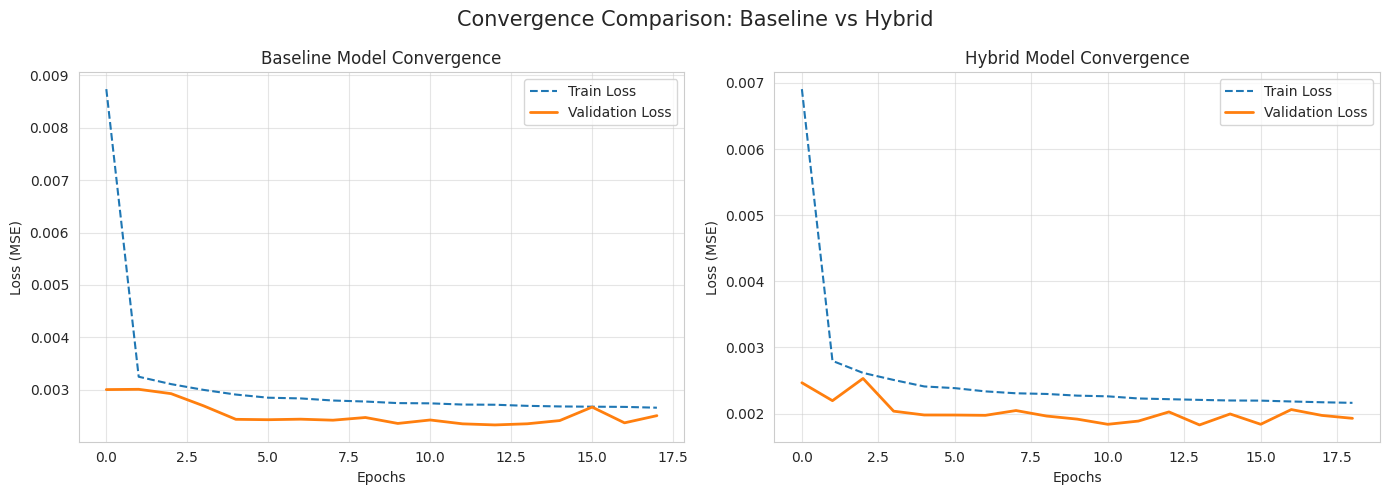

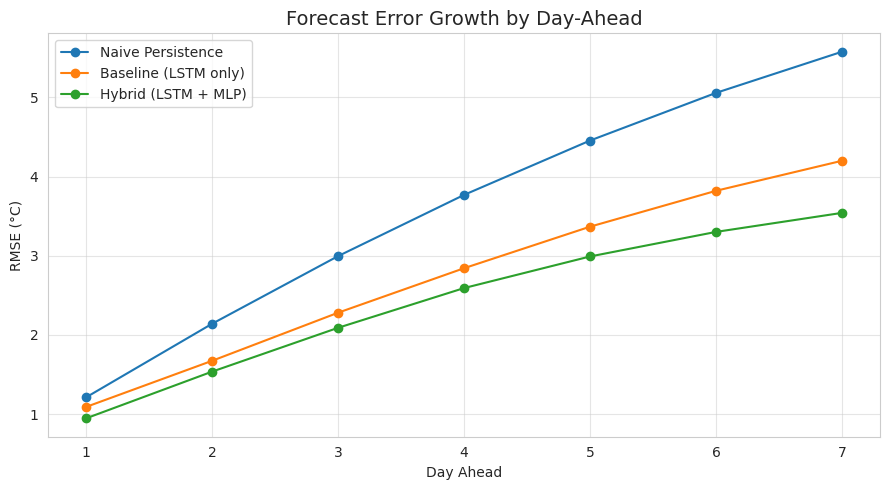

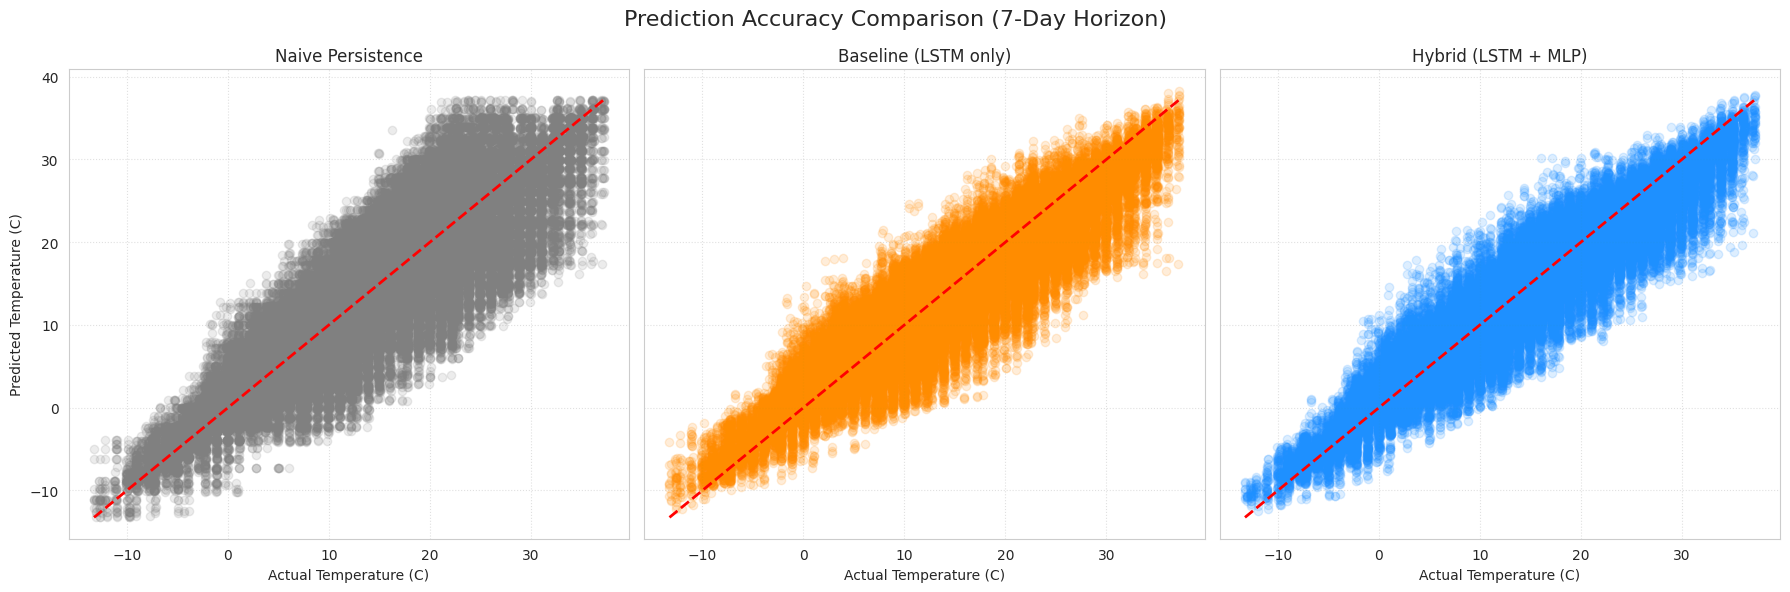

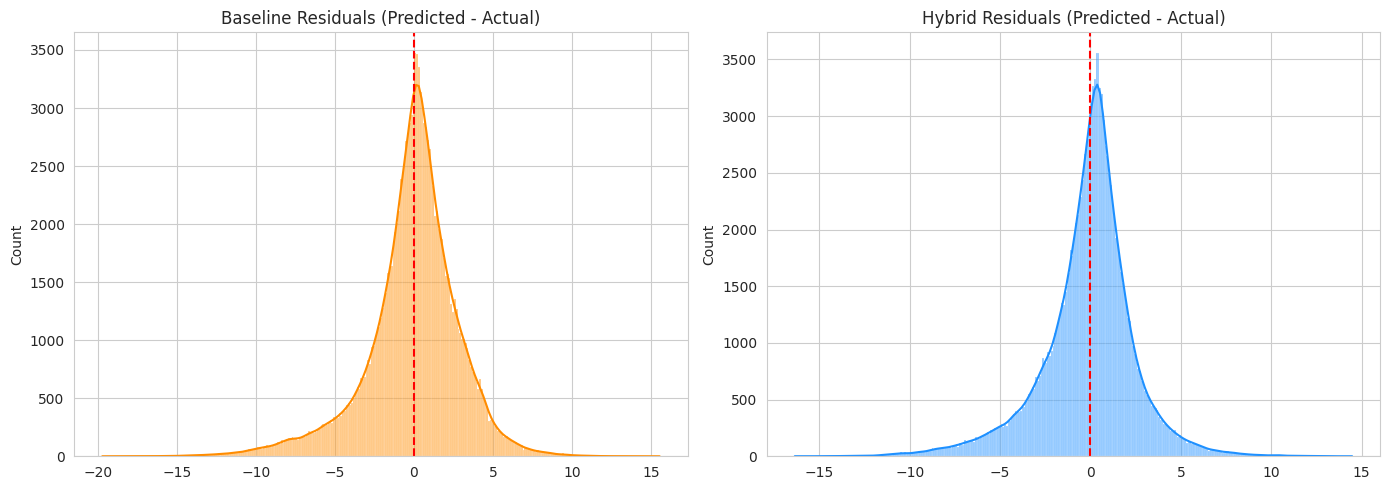

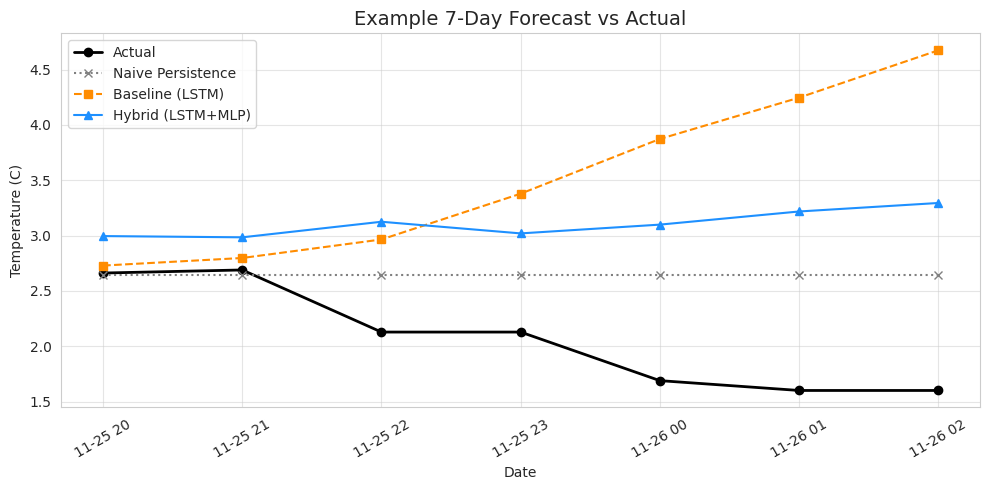

In [21]:
print("=" * 70)
print("PHASE 6: EVALUATION & MODEL COMPARISON")
print("=" * 70)

t_X_ts_test = torch.tensor(X_ts_test, dtype=torch.float32).to(DEVICE)
t_X_static_test = torch.tensor(X_static_test, dtype=torch.float32).to(DEVICE)

baseline_model.eval()
hybrid_model.eval()
with torch.no_grad():
    y_pred_base_scaled = baseline_model(t_X_ts_test).cpu().numpy()
    y_pred_hybrid_scaled = hybrid_model(t_X_ts_test, t_X_static_test).cpu().numpy()

y_pred_naive_scaled = naive_persistence_predict(X_ts_test)

y_test_real = scaler_target.inverse_transform(y_test)
y_pred_naive_real = scaler_target.inverse_transform(y_pred_naive_scaled)
y_pred_base_real = scaler_target.inverse_transform(y_pred_base_scaled)
y_pred_hybrid_real = scaler_target.inverse_transform(y_pred_hybrid_scaled)

models_real_preds = {
    "Naive Persistence": y_pred_naive_real,
    "Baseline (LSTM only)": y_pred_base_real,
    "Hybrid (LSTM + MLP)": y_pred_hybrid_real,
}

summary_rows = []
for name, preds in models_real_preds.items():
    mae = mean_absolute_error(y_test_real, preds)
    rmse = np.sqrt(mean_squared_error(y_test_real, preds))
    r2 = r2_score(y_test_real, preds)
    summary_rows.append({"Model": name, "MAE (°C)": mae, "RMSE (°C)": rmse, "R2": r2})

comparison_df = pd.DataFrame(summary_rows).set_index("Model")
print("\n--- Aggregate Comparison (averaged over all 7 forecast days) ---")
print(comparison_df.round(4))

per_day_rows = []
for name, preds in models_real_preds.items():
    for day in range(forecast_horizon):
        mae_d = mean_absolute_error(y_test_real[:, day], preds[:, day])
        rmse_d = np.sqrt(mean_squared_error(y_test_real[:, day], preds[:, day]))
        per_day_rows.append({"Model": name, "Day": day + 1, "MAE": mae_d, "RMSE": rmse_d})

per_day_df = pd.DataFrame(per_day_rows)
per_day_pivot_rmse = per_day_df.pivot(index="Day", columns="Model", values="RMSE")
print("\n--- RMSE by forecast day-ahead (°C) ---")
print(per_day_pivot_rmse.round(3))

hybrid_rmse_per_day = per_day_pivot_rmse["Hybrid (LSTM + MLP)"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_base["loss"], label="Train Loss", linestyle="--")
axes[0].plot(history_base["val_loss"], label="Validation Loss", linewidth=2)
axes[0].set_title("Baseline Model Convergence")
axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss (MSE)")
axes[0].legend(); axes[0].grid(True, alpha=0.5)

axes[1].plot(history_hybrid["loss"], label="Train Loss", linestyle="--")
axes[1].plot(history_hybrid["val_loss"], label="Validation Loss", linewidth=2)
axes[1].set_title("Hybrid Model Convergence")
axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Loss (MSE)")
axes[1].legend(); axes[1].grid(True, alpha=0.5)
plt.suptitle("Convergence Comparison: Baseline vs Hybrid", fontsize=15)
plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 5))
for name in models_real_preds:
    subset = per_day_df[per_day_df["Model"] == name]
    plt.plot(subset["Day"], subset["RMSE"], marker="o", label=name)
plt.title("Forecast Error Growth by Day-Ahead", fontsize=14)
plt.xlabel("Day Ahead"); plt.ylabel("RMSE (°C)")
plt.xticks(range(1, forecast_horizon + 1))
plt.legend(); plt.grid(True, alpha=0.5)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
min_v, max_v = float(np.min(y_test_real)), float(np.max(y_test_real))
colors = {"Naive Persistence": "gray", "Baseline (LSTM only)": "darkorange", "Hybrid (LSTM + MLP)": "dodgerblue"}
for ax, (name, preds) in zip(axes, models_real_preds.items()):
    ax.scatter(y_test_real.flatten(), preds.flatten(), alpha=0.15, color=colors[name])
    ax.plot([min_v, max_v], [min_v, max_v], color="red", linestyle="--", linewidth=2)
    ax.set_title(name)
    ax.set_xlabel("Actual Temperature (C)")
    ax.grid(True, linestyle=":", alpha=0.6)
axes[0].set_ylabel("Predicted Temperature (C)")
plt.suptitle("Prediction Accuracy Comparison (7-Day Horizon)", fontsize=16)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
resid_base = (y_pred_base_real - y_test_real).flatten()
resid_hybrid = (y_pred_hybrid_real - y_test_real).flatten()
sns.histplot(resid_base, kde=True, ax=axes[0], color="darkorange")
axes[0].set_title("Baseline Residuals (Predicted - Actual)")
axes[0].axvline(0, color="red", linestyle="--")
sns.histplot(resid_hybrid, kde=True, ax=axes[1], color="dodgerblue")
axes[1].set_title("Hybrid Residuals (Predicted - Actual)")
axes[1].axvline(0, color="red", linestyle="--")
plt.tight_layout(); plt.show()

sample_idx = len(X_ts_test) // 2
sample_dates = test_target_dates[sample_idx]
plt.figure(figsize=(10, 5))
plt.plot(sample_dates, y_test_real[sample_idx], marker="o", label="Actual", color="black", linewidth=2)
plt.plot(sample_dates, y_pred_naive_real[sample_idx], marker="x", label="Naive Persistence", linestyle=":", color="gray")
plt.plot(sample_dates, y_pred_base_real[sample_idx], marker="s", label="Baseline (LSTM)", linestyle="--", color="darkorange")
plt.plot(sample_dates, y_pred_hybrid_real[sample_idx], marker="^", label="Hybrid (LSTM+MLP)", color="dodgerblue")
plt.title("Example 7-Day Forecast vs Actual", fontsize=14)
plt.xlabel("Date"); plt.ylabel("Temperature (C)")
plt.xticks(rotation=30)
plt.legend(); plt.grid(True, alpha=0.5)
plt.tight_layout(); plt.show()

In [23]:
print("=" * 70)
print("PHASE 7: EXPORTING ARTIFACTS (ONNX MODEL + SCALERS + METRICS)")
print("=" * 70)

with open("scaler_ts.pkl", "wb") as f:
    pickle.dump(scaler_ts, f)
with open("scaler_static.pkl", "wb") as f:
    pickle.dump(scaler_static, f)
with open("scaler_target.pkl", "wb") as f:
    pickle.dump(scaler_target, f)

comparison_df.to_csv("model_comparison_metrics.csv")
with open("hybrid_rmse_per_day.pkl", "wb") as f:
    pickle.dump(hybrid_rmse_per_day, f)

hybrid_model_cpu = hybrid_model.to("cpu")
hybrid_model_cpu.eval()

dummy_ts = torch.randn(1, window_size, len(ts_features), dtype=torch.float32)
dummy_static = torch.randn(1, forecast_horizon * len(static_features), dtype=torch.float32)

torch.onnx.export(
    hybrid_model_cpu,
    (dummy_ts, dummy_static),
    "weather_hybrid_model_cpu.onnx",
    input_names=["Time_Series_Input", "Static_Input"],
    output_names=["Prediction_Output"],
    dynamic_axes={
        "Time_Series_Input": {0: "batch_size"},
        "Static_Input": {0: "batch_size"},
        "Prediction_Output": {0: "batch_size"},
    },
    opset_version=13,
    dynamo=False,
)

print("   weather_hybrid_model_cpu.onnx, scaler_ts.pkl, scaler_static.pkl,")
print("   scaler_target.pkl, model_comparison_metrics.csv, hybrid_rmse_per_day.pkl")

PHASE 7: EXPORTING ARTIFACTS (ONNX MODEL + SCALERS + METRICS)
   weather_hybrid_model_cpu.onnx, scaler_ts.pkl, scaler_static.pkl,
   scaler_target.pkl, model_comparison_metrics.csv, hybrid_rmse_per_day.pkl


/tmp/ipykernel_648/113179085.py:22: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4463: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(
